# TP Consigna
Usando la base de datos “Calidad_Agua.csv” realizar un modelo de regresión lineal que permita predecir la cantidad de partículas en suspensión (turbiedad) en relación a la demanda bioquímicia de oxígeno en el agua(dbo_mg_l).
 -	Graficar, evaluar sus métricas y analizar sus resultados.

## IMPORTACION LIBRERIAS - BASE

In [1336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [1337]:
df_nuevo = pd.read_csv("Calidad_Agua.csv", delimiter=",")
df_nuevo.head()

,sitios,fecha,tem_agua,tem_aire,od,ph,dbo_mg_l,dqo_mg_l,turbiedad_ntu
0,Canal Villanueva y Río Luján,22/2/2023,26.0,24.0,6.59,7.24,2.0,30.0,29.0
1,Río Lujan y Arroyo Caraguatá,22/2/2023,26.8,25.0,5.94,6.96,2.1,30.0,24.0
2,Canal Aliviador y Río Lujan,22/2/2023,27.6,24.0,6.14,6.88,4.1,30.0,21.0
3,Río Carapachay y Arroyo Gallo Fiambre,22/2/2023,26.1,25.0,5.02,6.82,2.2,30.0,28.0
4,Río Reconquista y Río Lujan,22/2/2023,25.9,24.0,5.28,6.69,3.3,30.0,24.0


## Mirar panorama general del dataset
tipos de datos que tiene y si contiene datos nulos

In [1338]:
df_nuevo.info()
#Los non-null son valores no nulos quiere decir que no tiene valores nulos
#si tiene 169 filas y dice 147 quiere decir que tiene 22 valores nulos en esa columna

<class 'pandas.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sitios         169 non-null    str    
 1   fecha          169 non-null    str    
 2   tem_agua       138 non-null    float64
 3   tem_aire       142 non-null    float64
 4   od             133 non-null    float64
 5   ph             125 non-null    float64
 6   dbo_mg_l       147 non-null    float64
 7   dqo_mg_l       151 non-null    float64
 8   turbiedad_ntu  151 non-null    float64
dtypes: float64(7), str(2)
memory usage: 12.0 KB


In [1339]:
#revisar cuantos valores nulos tiene cada columna
df_nuevo.isnull().sum() 

sitios            0
fecha             0
tem_agua         31
tem_aire         27
od               36
ph               44
dbo_mg_l         22
dqo_mg_l         18
turbiedad_ntu    18
dtype: int64

#### Imputar valores nulos con la media

In [1340]:
#imputar valores nulos con la media de la columna
#con simpleimputer de sklearn 

imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
columnas_con_nulos= ["tem_agua", "tem_aire", "od", "ph", "dbo_mg_l", "dqo_mg_l", "turbiedad_ntu"]

# fit_trsform es para que aprenda de los datos y luego transforme los datos
# que aprenda de los datos significa aprende de las media de cada columna para transformar esos valores nulos
#redondear los valores imputados
df_nuevo[columnas_con_nulos] = imputer.fit_transform(df_nuevo[columnas_con_nulos])
df_nuevo[columnas_con_nulos] = round(df_nuevo[columnas_con_nulos], 2)

In [1341]:
#Revisar si quedaron valores nulos
df_nuevo.isnull().sum()

sitios           0
fecha            0
tem_agua         0
tem_aire         0
od               0
ph               0
dbo_mg_l         0
dqo_mg_l         0
turbiedad_ntu    0
dtype: int64

### Explorar los datos
describe se usa para ver las columnas turbiedad_ntu y dbo_mg_l que son las que vamos a usar
con esta funcion se puede ver la media, std, min, max, 25%, 50%, 75%

In [1342]:
df_nuevo.describe()[["turbiedad_ntu", "dbo_mg_l"]]

,turbiedad_ntu,dbo_mg_l
count,169.000000,169.000000
mean,35.780118,4.208994
std,38.893490,3.351242
min,2.900000,2.000000
25%,17.000000,2.000000
50%,28.000000,3.600000
75%,40.000000,4.300000
max,432.000000,24.000000


### Visualizar con Boxplot


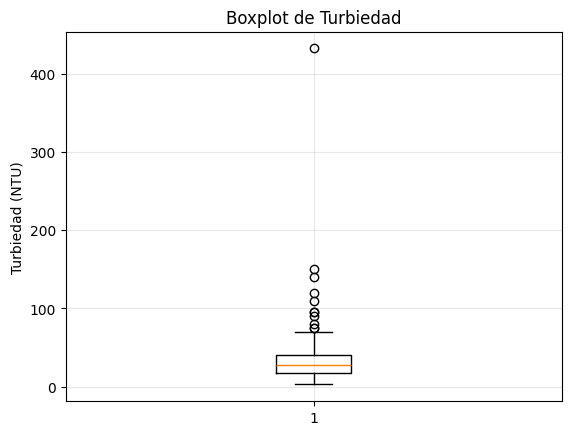

In [1343]:
plt.boxplot(df_nuevo["turbiedad_ntu"])
plt.ylabel("Turbiedad (NTU)")
plt.title("Boxplot de Turbiedad")
plt.grid(True, alpha=0.3)
plt.show()

In [1344]:
# metodo de Tukey para detectar outliers, se uso apuntes
#se calcula el primer cuartil y el tercer cuartil de la columna turbiedad_ntu
#este metodo se basa en la diferencia entre el tercer cuartil y el primer cuartil
Q1 = df_nuevo["turbiedad_ntu"].quantile(0.25)
Q3 = df_nuevo["turbiedad_ntu"].quantile(0.75)
IQR = Q3 - Q1

#se calculan los limites superior e inferior para determinar los outliers
#la cuenta es que si un valor es menor al limite inferior
# o mayor al limite superior se considera un outlier
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Limite inferior: -17.5
Limite superior: 74.5


In [1345]:
# Eliminar outliers
df_limpio = df_nuevo[(df_nuevo["turbiedad_ntu"] >= limite_inferior) &  (df_nuevo["turbiedad_ntu"] <= limite_superior)]

print(f"Datos originales: {len(df_nuevo)}")

#muestra como quedaria el dataset sin outliers
print(f"Datos sin outliers: {len(df_limpio)}")

Datos originales: 169
Datos sin outliers: 158


### Se uso df con Outlier para ver los resultados
Se opto por usar df_nuevo
- X: dbo (demanda bioquimica de oxigeno)	Variable que PREDICE
- y: Turbiedad (particulas en suspension) Variable a PREDECIR

In [1346]:
#seleccionar la variable observada y variable respuesta
# variable observada es la que queremos predecir, en este caso turbiedad_ntu
x = pd.DataFrame(df_nuevo, columns=['dbo_mg_l'])
y = pd.DataFrame(df_nuevo, columns=['turbiedad_ntu'])


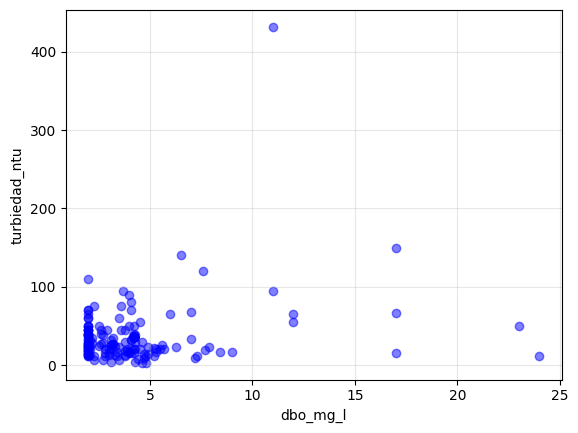

In [1347]:
# graficar variable observada y la variable respuesta
plt.scatter(x, y, alpha=0.5, color='b', label='Datos')
plt.xlabel("dbo_mg_l")
plt.ylabel("turbiedad_ntu")
plt.grid(True, alpha=0.3)
plt.show()

## Preparar las variables

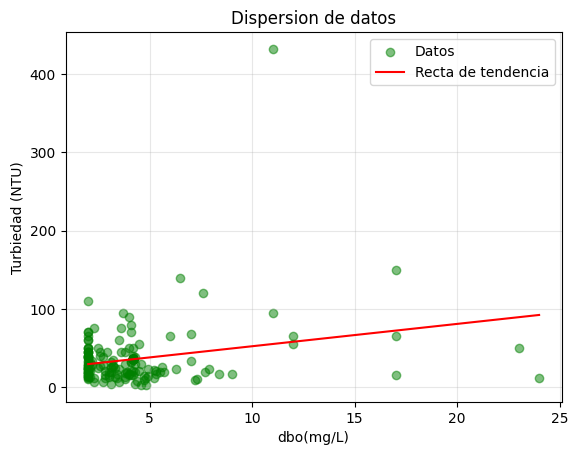

In [1348]:
#Reshape recontruye el dataframe a 1 columna para que sklearn pueda trabajar
# usar nombres diferentes en las variables(X, Y) para no sobrescribir los DataFrames originales (x, y)
X = x.values.reshape(-1, 1)
Y = y.values

# se entrenan los datos con el modelo de regresion lineal para obtener la recta de tendencia
modelo = LinearRegression()
modelo.fit(X, Y)

#valores para la recta
x_linea = np.linspace(X.min(), X.max(), 50).reshape(-1, 1)
y_linea = modelo.predict(x_linea)


#Graficar recta de tendencia
plt.scatter(X, Y, color="green", alpha=0.5, label="Datos")
plt.plot(x_linea, y_linea, color="red", label="Recta de tendencia")


plt.xlabel("dbo(mg/L)")
plt.ylabel("Turbiedad (NTU)")
plt.title("Dispersion de datos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Separar datos para entrenar

In [1349]:
# usar train_test_split con los DataFrames originales (x, y), no con los arrays (X, Y), 
# si no tira error y x_test sigue siendo un DataFrame y se puede usar .head()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
x_test.head()

,dbo_mg_l
42,2.00
23,3.50
45,2.00
48,2.00
13,4.21


In [1350]:
#dimensiones de los conjuntos de entrenamiento 80% 
# "x" es dbo y "y" es turbiedad
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

#datos para prueba 20%
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (135, 1)
y_train shape: (135, 1)
X_test shape: (34, 1)
y_test shape: (34, 1)


### Entrenar el modelo

In [1351]:
#Se crea modelo de regresion lineal
modelo_nuevo = LinearRegression()

#este modelo se entrena con los datos Train
modelo_nuevo.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[2.24]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['dbo_mg_l']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[27.02]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [1352]:
# se crea la variable prediccion para guardar los valores predichos
# entonces desde modelo nuevo se llama a predict y se le pasa x_test 
# con prediccion se busca predecir la turbiedad a partir de los valores de DBO
prediccion = modelo_nuevo.predict(x_test)

# se usa np.array para convertir la prediccion en un array de tipo float
prediccion= np.array(prediccion, dtype=float)
prediccion

array([[31.49220883],
       [34.84510839],
       [31.49220883],
       [31.49220883],
       [36.43214752],
       [31.9392621 ],
       [34.84510839],
       [33.95100184],
       [36.18626822],
       [31.49220883],
       [36.18626822],
       [31.49220883],
       [36.43214752],
       [36.43214752],
       [44.23322718],
       [32.60984201],
       [34.62158175],
       [31.49220883],
       [36.63332149],
       [36.63332149],
       [37.08037477],
       [31.49220883],
       [31.71573546],
       [35.96274158],
       [38.86858787],
       [36.40979486],
       [31.49220883],
       [37.52742804],
       [53.8448726 ],
       [36.18626822],
       [31.49220883],
       [65.02120448],
       [33.28042193],
       [53.8448726 ]])

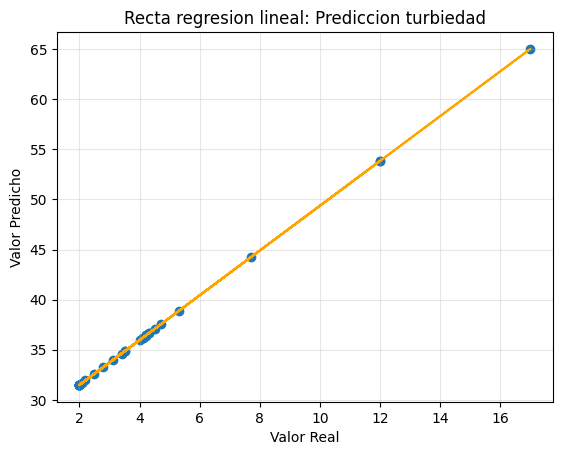

In [1353]:
#graficar la recta de regresion del modelo predictivo
# recordar que "x" es dbo y "y" es turbiedad
#se uso values para convertir esto para que sklearn pueda trabajar con los datos
X_test_array = x_test.values

# x_test pertece al conjunto de prueba de la variable dbo
plt.scatter(X_test_array, prediccion)
plt.plot(X_test_array, prediccion, "orange")

plt.xlabel("Valor Real") 
plt.ylabel("Valor Predicho")
plt.title("Recta regresion lineal: Prediccion turbiedad")
plt.grid(True, alpha=0.3)
plt.show()


### Ver valores reales y los valores predichos

In [1354]:
#comparar en una tabla los valores reales y los valores predichos
y_test = np.array(y_test, dtype=float)

# flatten() es para convertir el array de 2 dimensiones a 1 dimension
#se crea un DataFrame con los valores reales y los valores predichos
#redondear los valores predichos a 2 decimales
prediccion_mostrar = np.round(prediccion, 2)
df_new = pd.DataFrame({"Valor real": y_test.flatten(), "Prediccion": prediccion_mostrar.flatten()})
#mostrar los primeros 10 valores reales y predichos
df_new.head(10)


,Valor real,Prediccion
0,45.00,31.49
1,23.00,34.85
2,50.00,31.49
3,50.00,31.49
4,35.78,36.43
5,28.00,31.94
6,6.00,34.85
7,26.00,33.95
8,32.00,36.19
9,50.00,31.49


### Metricas

In [1355]:
Valor_real = y_test.flatten()
Valor_predicho = prediccion.flatten()

# Calcular metricas
mae = mean_absolute_error(Valor_real, Valor_predicho)
mse = mean_squared_error(Valor_real, Valor_predicho)

#con np.sqrt se calcula la raiz cuadrada del mse para obtener el rmse
#es lo mismo que rmse=mse**(1/2.0)
rmse = np.sqrt(mse)
varianza = r2_score(Valor_real, Valor_predicho)

# mostrar las metricas que se obtuvieron
print("Mean Absolute Error (MAE):%.2f" % mae)
print("Mean Squared Error (MSE):%.2f" % mse)
print("Root Mean Squared Error (RMSE):%.2f" % rmse)
print("Variance Score: %.2f" % varianza)

Mean Absolute Error (MAE):14.01
Mean Squared Error (MSE):407.03
Root Mean Squared Error (RMSE):20.18
Variance Score: 0.33


## Analizar resultados
El Modelo no es bueno para predecir la turbiedad apartir de la demanda bioquimica de oxigeno en el agua. No se logra ajustar bien a los datos. 
-  El puntaje de varianza es bajo no llega a 1, tienen una relacion muy debil, algo a mejorar podria ser sumar mas variables.


# TP Consigna II

Usando la base de datos “Calidad_Agua.csv” realizar un modelo de regresión polinómica de grado: 2, 3 y 4 que permita encontrar la curva que mejor describa la relación entre la cantidad de partículas en suspensión (turbiedad) y la demanda bioquímicia de oxígeno en el agua.

   -  Graficar, evaluar sus métricas y analizar sus resultados.


#### Usar Dataframe df_nuevo que se cargo al inicio

In [1356]:
df_nuevo.head(4)

,sitios,fecha,tem_agua,tem_aire,od,ph,dbo_mg_l,dqo_mg_l,turbiedad_ntu
0,Canal Villanueva y Río Luján,22/2/2023,26.0,24.0,6.59,7.24,2.0,30.0,29.0
1,Río Lujan y Arroyo Caraguatá,22/2/2023,26.8,25.0,5.94,6.96,2.1,30.0,24.0
2,Canal Aliviador y Río Lujan,22/2/2023,27.6,24.0,6.14,6.88,4.1,30.0,21.0
3,Río Carapachay y Arroyo Gallo Fiambre,22/2/2023,26.1,25.0,5.02,6.82,2.2,30.0,28.0


In [1357]:
### Crear df para el modelo de regresion polinomica
# usar las columnas dbo_mg_l y turbiedad_ntu
df_polinomica = df_nuevo.copy()
df_polinomica = df_polinomica[['dbo_mg_l', 'turbiedad_ntu']]
df_polinomica.head(4)

,dbo_mg_l,turbiedad_ntu
0,2.0,29.0
1,2.1,24.0
2,4.1,21.0
3,2.2,28.0


In [1358]:
df_polinomica.info()

<class 'pandas.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dbo_mg_l       169 non-null    float64
 1   turbiedad_ntu  169 non-null    float64
dtypes: float64(2)
memory usage: 2.8 KB


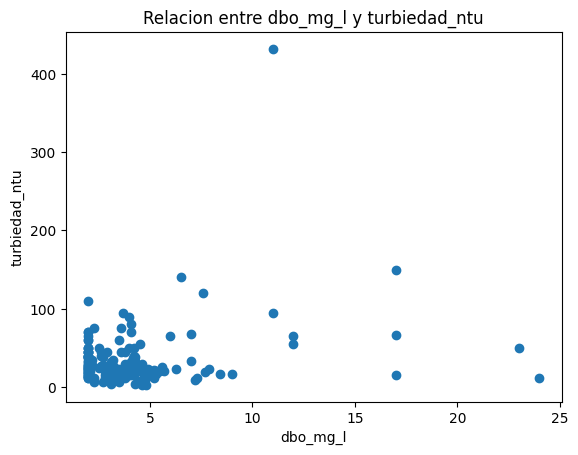

In [1359]:
#seleccionar la variable observada y variable respuesta
#la variable observada es la que queremos predecir, en este caso turbiedad_ntu
x_polinomica = np.array(df_polinomica['dbo_mg_l'], dtype=float)
y_polinomica= np.array(df_polinomica['turbiedad_ntu'], dtype=float)

plt.scatter(x_polinomica, y_polinomica)
plt.xlabel('dbo_mg_l')
plt.ylabel('turbiedad_ntu')
plt.title('Relacion entre dbo_mg_l y turbiedad_ntu')
plt.show()

### Separar datos de entrenamiento

In [1360]:
#separar los datos en conjunto de entrenamiento y conjunto de prueba
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(x_polinomica, y_polinomica, test_size=0.2, random_state=2)
y_test_p

array([ 45.  ,  23.  ,  50.  ,  50.  ,  35.78,  28.  ,   6.  ,  26.  ,
        32.  ,  50.  ,  21.  ,  14.  ,  35.78,  35.78,  19.  ,  24.  ,
        17.  ,  23.  ,  39.  ,  20.  ,  21.  ,  27.  ,  13.  ,  50.  ,
        21.  ,  37.  ,  13.  ,  14.  ,  55.  ,  32.  ,  22.  , 150.  ,
        21.  ,  65.  ])

In [1361]:
print("x_train_p shape:", x_train_p.shape)
print("y_train_p shape:", y_train_p.shape)
print("x_test_p shape:", x_test_p.shape)
print("y_test_p shape:", y_test_p.shape)

x_train_p

x_train_p shape: (135,)
y_train_p shape: (135,)
x_test_p shape: (34,)
y_test_p shape: (34,)


array([ 2.  ,  2.6 ,  2.  ,  2.  ,  3.4 ,  4.6 ,  4.1 ,  7.3 ,  4.21,
        2.  ,  3.8 ,  4.21, 24.  ,  4.21,  2.7 ,  2.3 ,  2.  ,  3.9 ,
        4.6 ,  2.  ,  3.1 ,  4.21,  2.7 ,  2.  ,  2.  ,  2.  ,  3.2 ,
        4.21,  3.2 ,  2.  ,  3.8 ,  2.8 , 17.  ,  4.7 ,  3.  ,  2.5 ,
        6.5 ,  2.  ,  4.21,  9.  ,  3.1 ,  2.  ,  5.6 ,  2.  ,  2.  ,
        4.9 ,  3.1 ,  4.9 , 23.  ,  3.  ,  2.  ,  2.  ,  4.21,  2.  ,
        4.21,  2.8 ,  4.21,  5.5 ,  4.21,  2.  ,  2.1 ,  2.  ,  2.  ,
        6.  ,  4.  ,  3.8 ,  2.  ,  4.21,  2.1 ,  4.21, 11.  ,  3.7 ,
        4.21,  2.  ,  2.3 ,  6.3 ,  4.1 ,  8.4 ,  4.3 ,  2.1 ,  7.  ,
        4.  ,  2.3 ,  2.  ,  2.  ,  5.2 ,  3.6 ,  4.5 ,  4.1 ,  7.  ,
        2.7 ,  2.  ,  4.4 ,  4.21,  2.2 ,  3.3 ,  2.  , 11.  ,  5.7 ,
        2.  ,  4.21,  4.8 ,  7.2 ,  3.1 ,  2.6 ,  2.  ,  4.3 ,  2.  ,
        3.8 ,  3.9 ,  2.  ,  3.5 ,  4.8 ,  4.21,  2.  ,  5.2 ,  3.3 ,
        4.21,  3.8 ,  4.21,  4.  , 17.  ,  7.6 ,  2.9 ,  3.6 ,  5.3 ,
        2.  ,  2.  ,

## Crear Modelo  - Grado 2
Grado 2: [x, x²]

### Transformacion - Grado 2

In [1362]:
#se cra un objeto de la clase PolynomialFeatures con grado 2
# include_bias=False significa que no se incluye el termino constante (bias)
# Transformar los datos de entrenamiento a un polinomio de grado 2
polinom_2 = PolynomialFeatures(degree=2, include_bias=False)

x_poli = polinom_2.fit_transform(x_train_p.reshape(-1, 1)) # recordar quereshape para que sea una matriz de 2D

x_poli

array([[  2.    ,   4.    ],
       [  2.6   ,   6.76  ],
       [  2.    ,   4.    ],
       [  2.    ,   4.    ],
       [  3.4   ,  11.56  ],
       [  4.6   ,  21.16  ],
       [  4.1   ,  16.81  ],
       [  7.3   ,  53.29  ],
       [  4.21  ,  17.7241],
       [  2.    ,   4.    ],
       [  3.8   ,  14.44  ],
       [  4.21  ,  17.7241],
       [ 24.    , 576.    ],
       [  4.21  ,  17.7241],
       [  2.7   ,   7.29  ],
       [  2.3   ,   5.29  ],
       [  2.    ,   4.    ],
       [  3.9   ,  15.21  ],
       [  4.6   ,  21.16  ],
       [  2.    ,   4.    ],
       [  3.1   ,   9.61  ],
       [  4.21  ,  17.7241],
       [  2.7   ,   7.29  ],
       [  2.    ,   4.    ],
       [  2.    ,   4.    ],
       [  2.    ,   4.    ],
       [  3.2   ,  10.24  ],
       [  4.21  ,  17.7241],
       [  3.2   ,  10.24  ],
       [  2.    ,   4.    ],
       [  3.8   ,  14.44  ],
       [  2.8   ,   7.84  ],
       [ 17.    , 289.    ],
       [  4.7   ,  22.09  ],
       [  3.  

In [1363]:
# Crear y entrenar Modelo
#se crea un objeto de la clase LinearRegression para el modelo polinomico
#esto se hace porque la regresion polinomica es una regresion lineal sobre las variables transformadas
modelo_poli2 = LinearRegression()
modelo_poli2.fit(x_poli, y_train_p)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 8.88,-0.32]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.358
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[867.92, 12.81]"


In [1364]:
# transformar los datos de test a un polinomio de grado 2
x_test_poli = polinom_2.fit_transform(x_test_p.reshape(-1, 1))
x_test_poli

array([[  2.    ,   4.    ],
       [  3.5   ,  12.25  ],
       [  2.    ,   4.    ],
       [  2.    ,   4.    ],
       [  4.21  ,  17.7241],
       [  2.2   ,   4.84  ],
       [  3.5   ,  12.25  ],
       [  3.1   ,   9.61  ],
       [  4.1   ,  16.81  ],
       [  2.    ,   4.    ],
       [  4.1   ,  16.81  ],
       [  2.    ,   4.    ],
       [  4.21  ,  17.7241],
       [  4.21  ,  17.7241],
       [  7.7   ,  59.29  ],
       [  2.5   ,   6.25  ],
       [  3.4   ,  11.56  ],
       [  2.    ,   4.    ],
       [  4.3   ,  18.49  ],
       [  4.3   ,  18.49  ],
       [  4.5   ,  20.25  ],
       [  2.    ,   4.    ],
       [  2.1   ,   4.41  ],
       [  4.    ,  16.    ],
       [  5.3   ,  28.09  ],
       [  4.2   ,  17.64  ],
       [  2.    ,   4.    ],
       [  4.7   ,  22.09  ],
       [ 12.    , 144.    ],
       [  4.1   ,  16.81  ],
       [  2.    ,   4.    ],
       [ 17.    , 289.    ],
       [  2.8   ,   7.84  ],
       [ 12.    , 144.    ]])

### Predicciones  - Grado 2

In [1365]:
#crear las predicciones del modelo
prediccion_poli2 = modelo_poli2.predict(x_test_poli)
prediccion_poli2

array([24.84149672, 35.54064241, 24.84149672, 24.84149672, 40.1077606 ,
       26.3504263 , 35.54064241, 32.82694382, 39.42108995, 24.84149672,
       39.42108995, 24.84149672, 40.1077606 , 40.1077606 , 57.91324632,
       28.56629558, 34.87172278, 24.84149672, 40.66387903, 40.66387903,
       41.8813214 , 24.84149672, 25.59912985, 38.79019039, 46.49762376,
       40.04565283, 24.84149672, 43.07341706, 69.23825153, 39.42108995,
       24.84149672, 67.67408501, 30.72513475, 69.23825153])

### Predicciones para graficar

In [1366]:
#se genera un rango de valores entre el minimo y el maximo de la columna dbo_mg_l
x_fit = np.linspace(df_polinomica["dbo_mg_l"].min(), df_polinomica["dbo_mg_l"].max(), 200).reshape(-1,1)

#cada valor de x_fit se convierte en: x, x^2
x_fit_poly =polinom_2.transform(x_fit)

#se llama al modelo x_fit_poly para generar las predicciones
# y_fit es la curva ajustada al modelo de regresion, 
# quiere decir que es la curva que mejor se ajusta a los datos
y_fit = modelo_poli2.predict(x_fit_poly) 


### Graficar  - Grado 2

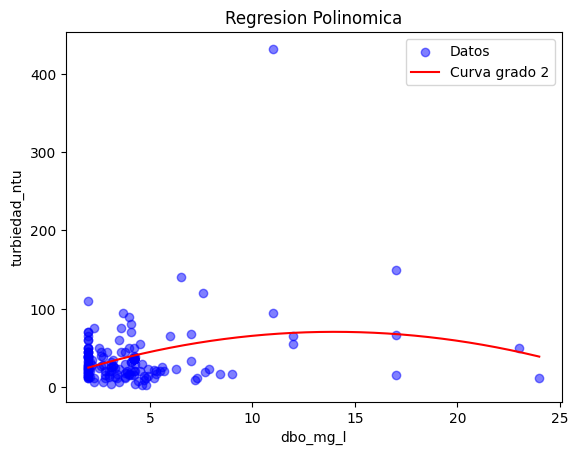

In [1367]:
#con esto se grafican los datos originales y la curva ajustada al modelo
plt.scatter(x_polinomica, y_polinomica, alpha=0.5, color='b', label='Datos')
plt.plot(x_fit, y_fit, color='r', label='Curva grado 2')
plt.xlabel('dbo_mg_l')
plt.ylabel('turbiedad_ntu')
plt.title('Regresion Polinomica')
plt.legend()
plt.show()

#### Ecuacion polinomica del modelo - Grado 2
esta es la ecuacion del polinomio de grado 2 que se ajusta a los datos,
se puede usar esta ecuacion para predecir la turbiedad a partir de los valores de dbo_mg_l

In [1368]:
# crear coeficientes del modelo polinomico
coef = modelo_poli2.coef_
coef

array([ 8.87535035, -0.31683392])

In [1369]:
# se extraen los coeficientes del modelo polinomico
#esto es para obtener los coeficientes de la ecuacion polinomica que se ajusta a los datos
a_coef = coef[0]
b_coef = coef[1]

#se redondean los coef a 4 decimales para que sea mas facil de leer
a_coef=np.round(a_coef, 4)
b_coef=np.round(b_coef, 4)

a_coef

np.float64(8.8754)

In [1370]:
#hallar el intercepto del modelo polinomico
a_intercept = modelo_poli2.intercept_
b_intercept = np.round(a_intercept, 4)

a_intercept

np.float64(8.35813170249395)

In [1371]:
# Formula del polinomio de grado 2 y=a2.x^2+a1.x+a0
print("Ecuacion polinómica  de grd.2:  y=",a_coef,"*x^2+",b_coef,"x","+",a_intercept)

Ecuacion polinómica  de grd.2:  y= 8.8754 *x^2+ -0.3168 x + 8.35813170249395


### Valores reales y Valores Predichos  - Grado 2

In [1372]:
# Crear data frame entre VR y VP
# Se crea un dataframe para visualizar y comparar las predicciones con el valor real
df_visualizacion= pd.DataFrame({'Valor_R':y_test_p,'Valor_P':prediccion_poli2.round(2)})
df_visualizacion.head(10)

,Valor_R,Valor_P
0,45.00,24.84
1,23.00,35.54
2,50.00,24.84
3,50.00,24.84
4,35.78,40.11
5,28.00,26.35
6,6.00,35.54
7,26.00,32.83
8,32.00,39.42
9,50.00,24.84


### Metricas - Grado 2

In [1373]:
#metricas del modelo polinomico
y_test_2 = y_test_p
prediccion_2 = prediccion_poli2

mae_2 = mean_absolute_error(y_test_2, prediccion_2)
mse_2 = mean_squared_error(y_test_2, prediccion_2)
rmse_2 = np.sqrt(mse_2)
varianza_2 = r2_score(y_test_2, prediccion_2)


print("Mean Absolute Error (MAE):%.2f" % mae_2)
print("Mean Squared Error (MSE):%.2f" % mse_2)
print("Root Mean Squared Error (RMSE):%.2f" % rmse_2)
print("Variance Score: %.2f" % varianza_2)

Mean Absolute Error (MAE):15.25
Mean Squared Error (MSE):463.71
Root Mean Squared Error (RMSE):21.53
Variance Score: 0.23


## Crear Modelo - Grado 3

Grado 3: [x, x², x³] = [2, 4, 8]

### Transformacion - Grado 3

In [1374]:
#transformar los datos de entrenamiento a un polinomio de grado 3
polinom_3 = PolynomialFeatures(degree=3, include_bias=False)
x_poli_3 = polinom_3.fit_transform(x_train_p.reshape(-1, 1))

x_poli_3

array([[2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [2.6000000e+00, 6.7600000e+00, 1.7576000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [3.4000000e+00, 1.1560000e+01, 3.9304000e+01],
       [4.6000000e+00, 2.1160000e+01, 9.7336000e+01],
       [4.1000000e+00, 1.6810000e+01, 6.8921000e+01],
       [7.3000000e+00, 5.3290000e+01, 3.8901700e+02],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [3.8000000e+00, 1.4440000e+01, 5.4872000e+01],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [2.4000000e+01, 5.7600000e+02, 1.3824000e+04],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [2.7000000e+00, 7.2900000e+00, 1.9683000e+01],
       [2.3000000e+00, 5.2900000e+00, 1.2167000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [3.9000000e+00, 1.5210000e+01, 5.9319000e+01],
       [4.6000000e+00, 2.116

In [1375]:
# Crear y entrenar Modelo
#se crea un objeto de la clase LinearRegression para el modelo polinomico
#esto se hace porque la regresion polinomica es una regresion lineal sobre las variables transformadas
modelo_poli3 = LinearRegression()
modelo_poli3.fit(x_poli_3, y_train_p)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-10.25, 2.15, -0.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,44.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[19412.94, 161.75, 5.43]"


In [1376]:
#transformar datos de test a grado 3
x_test_poli3 = polinom_3.fit_transform(x_test_p.reshape(-1, 1))
x_test_poli3

array([[2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [3.5000000e+00, 1.2250000e+01, 4.2875000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [2.2000000e+00, 4.8400000e+00, 1.0648000e+01],
       [3.5000000e+00, 1.2250000e+01, 4.2875000e+01],
       [3.1000000e+00, 9.6100000e+00, 2.9791000e+01],
       [4.1000000e+00, 1.6810000e+01, 6.8921000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [4.1000000e+00, 1.6810000e+01, 6.8921000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [4.2100000e+00, 1.7724100e+01, 7.4618461e+01],
       [7.7000000e+00, 5.9290000e+01, 4.5653300e+02],
       [2.5000000e+00, 6.2500000e+00, 1.5625000e+01],
       [3.4000000e+00, 1.1560000e+01, 3.9304000e+01],
       [2.0000000e+00, 4.0000000e+00, 8.0000000e+00],
       [4.3000000e+00, 1.849

### Predicciones - Grado 3

In [1377]:
#crear las predicciones del modelo
prediccion_poli3 = modelo_poli3.predict(x_test_poli3)
prediccion_poli3

array([ 31.6560352 ,  31.42049129,  31.6560352 ,  31.6560352 ,
        33.53974651,  31.21562264,  31.42049129,  30.82097186,
        33.12802274,  31.6560352 ,  33.12802274,  31.6560352 ,
        33.53974651,  33.53974651,  58.50122585,  30.80226999,
        31.22861671,  31.6560352 ,  33.89826884,  33.89826884,
        34.76302234,  31.6560352 ,  31.41904315,  32.77947004,
        39.09478536,  33.50110635,  31.6560352 ,  35.718667  ,
       101.04249657,  33.12802274,  31.6560352 , 122.06439131,
        30.67478801, 101.04249657])

### Predicciones para graficar

In [1378]:
#cada valor de x_fit se convierte en: x, x^2, x^3
x_fit_3 = np.linspace(df_polinomica["dbo_mg_l"].min(), df_polinomica["dbo_mg_l"].max(), 200).reshape(-1,1)

x_fit_poli_3 =polinom_3.transform(x_fit_3)
#se llama al modelo para generar las predicciones
y_fit_3 = modelo_poli3.predict(x_fit_poli_3) 

### Graficar - Grado 3

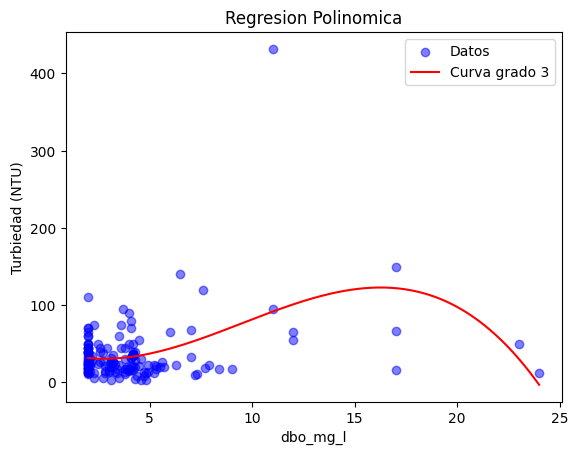

In [1379]:
#con esto se grafican los datos originales y la curva ajustada al modelo
plt.scatter(x_polinomica, y_polinomica, alpha=0.5, color='b', label='Datos')
plt.plot(x_fit_3, y_fit_3, color='r', label='Curva grado 3')
plt.xlabel('dbo_mg_l')
plt.ylabel('Turbiedad (NTU)')
plt.title('Regresion Polinomica')
plt.legend()
plt.show()

### Valores reales y Valores Predichos - Grado 3

In [1380]:
# df para visualizar y comparar las predicciones con el valor real
df_visualizacion3= pd.DataFrame({'Valor_R':y_test_p,'Valor_P':prediccion_poli3.round(2)})
df_visualizacion3.head(10)

,Valor_R,Valor_P
0,45.00,31.66
1,23.00,31.42
2,50.00,31.66
3,50.00,31.66
4,35.78,33.54
5,28.00,31.22
6,6.00,31.42
7,26.00,30.82
8,32.00,33.13
9,50.00,31.66


### Metricas - Grado 3

In [1381]:
#metricas del modelo polinomico
y_test_3 = y_test_p
prediccion_3 = prediccion_poli3

mae_3 = mean_absolute_error(y_test_3, prediccion_3)
mse_3 = mean_squared_error(y_test_3, prediccion_3)
rmse_3 = np.sqrt(mse_3)
varianza_3 = r2_score(y_test_3, prediccion_3)


print("Mean Absolute Error (MAE):%.2f" % mae_3)
print("Mean Squared Error (MSE):%.2f" % mse_3)
print("Root Mean Squared Error (RMSE):%.2f" % rmse_3)
print("Variance Score: %.2f" % varianza_3)

Mean Absolute Error (MAE):14.19
Mean Squared Error (MSE):320.89
Root Mean Squared Error (RMSE):17.91
Variance Score: 0.47


## Crear Modelo - Grado 4

Grado 4: [x, x², x³, x⁴] = [2, 4, 8, 16]

### Transformacion - Grado 4

In [1382]:
#transformar los datos de entrenamiento a un polinomio de grado 4
polinom_4 = PolynomialFeatures(degree=4, include_bias=False)
x_poli_4 = polinom_4.fit_transform(x_train_p.reshape(-1, 1))

x_poli_4

array([[2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [2.60000000e+00, 6.76000000e+00, 1.75760000e+01, 4.56976000e+01],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [3.40000000e+00, 1.15600000e+01, 3.93040000e+01, 1.33633600e+02],
       [4.60000000e+00, 2.11600000e+01, 9.73360000e+01, 4.47745600e+02],
       [4.10000000e+00, 1.68100000e+01, 6.89210000e+01, 2.82576100e+02],
       [7.30000000e+00, 5.32900000e+01, 3.89017000e+02, 2.83982410e+03],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e+01, 3.14143721e+02],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [3.80000000e+00, 1.44400000e+01, 5.48720000e+01, 2.08513600e+02],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e+01, 3.14143721e+02],
       [2.40000000e+01, 5.76000000e+02, 1.38240000e+04, 3.31776000e+05],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e

In [1383]:
#se crea un objeto de la clase LinearRegression para el modelo polinomico
#esto se hace porque la regresion polinomica es una regresion lineal sobre las variables transformadas
modelo_poli4 = LinearRegression()
modelo_poli4.fit(x_poli_4, y_train_p)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-65.92, 13.56, -0.87, 0.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,122.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[444683.53, 2228.56, 61.28, 2.17]"


In [1384]:
#transformar datos de test a grado 4
x_test_poli4 = polinom_4.fit_transform(x_test_p.reshape(-1, 1))
x_test_poli4

array([[2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [3.50000000e+00, 1.22500000e+01, 4.28750000e+01, 1.50062500e+02],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e+01, 3.14143721e+02],
       [2.20000000e+00, 4.84000000e+00, 1.06480000e+01, 2.34256000e+01],
       [3.50000000e+00, 1.22500000e+01, 4.28750000e+01, 1.50062500e+02],
       [3.10000000e+00, 9.61000000e+00, 2.97910000e+01, 9.23521000e+01],
       [4.10000000e+00, 1.68100000e+01, 6.89210000e+01, 2.82576100e+02],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [4.10000000e+00, 1.68100000e+01, 6.89210000e+01, 2.82576100e+02],
       [2.00000000e+00, 4.00000000e+00, 8.00000000e+00, 1.60000000e+01],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e+01, 3.14143721e+02],
       [4.21000000e+00, 1.77241000e+01, 7.46184610e

### Predicciones - Grado 4

In [1385]:
#crear las predicciones del modelo
prediccion_poli4 = modelo_poli4.predict(x_test_poli4)
prediccion_poli4

array([ 38.55268949,  23.36484021,  38.55268949,  38.55268949,
        25.8770986 ,  34.57143081,  23.36484021,  24.37631997,
        25.16772402,  38.55268949,  25.16772402,  38.55268949,
        25.8770986 ,  25.8770986 ,  81.09788031,  29.83268561,
        23.43849243,  38.55268949,  26.53625383,  26.53625383,
        28.24143742,  38.55268949,  36.47696491,  24.61841069,
        37.8932244 ,  25.80817636,  38.55268949,  30.25599919,
       133.93729547,  25.16772402,  38.55268949,  77.656916  ,
        26.47158052, 133.93729547])

### Predicciones para graficar

In [1386]:
#cada valor de x_fit se convierte en: x, x^2, x^3, x^4
x_fit_4 = np.linspace(df_polinomica["dbo_mg_l"].min(), df_polinomica["dbo_mg_l"].max(), 200).reshape(-1,1)

x_fit_poli_4 =polinom_4.transform(x_fit_4)
#se llama al modelo para generar las predicciones
y_fit_4 = modelo_poli4.predict(x_fit_poli_4) 

### Graficar - Grado 4

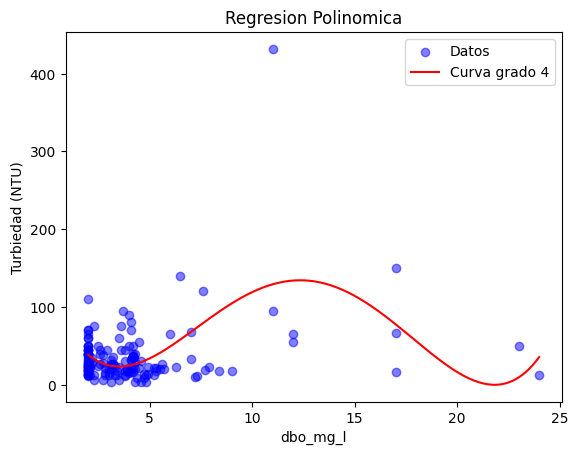

In [1387]:
#con esto se grafican los datos originales y la curva ajustada al modelo
plt.scatter(x_polinomica, y_polinomica, alpha=0.5, color='b', label='Datos')
plt.plot(x_fit_4, y_fit_4, color='r', label='Curva grado 4')
plt.xlabel('dbo_mg_l')
plt.ylabel('Turbiedad (NTU)')
plt.title('Regresion Polinomica')
plt.legend()
plt.show()

### Metricas - Grado 4

In [1388]:
#metricas del modelo polinomico
y_test_4 = y_test_p
prediccion_4 = prediccion_poli4

mae_4 = mean_absolute_error(y_test_4, prediccion_4)
mse_4 = mean_squared_error(y_test_4, prediccion_4)
rmse_4= np.sqrt(mse_4)
varianza_4 = r2_score(y_test_4, prediccion_4)


print("Mean Absolute Error (MAE):%.2f" % mae_4)
print("Mean Squared Error (MSE):%.2f" % mse_4)
print("Root Mean Squared Error (RMSE):%.2f" % rmse_4)
print("Variance Score: %.2f" % varianza_4)

Mean Absolute Error (MAE):18.46
Mean Squared Error (MSE):746.81
Root Mean Squared Error (RMSE):27.33
Variance Score: -0.24


### Analizar todos los resultados

In [1389]:
#crear un dataframe con los resultados de los modelos polinomicos
resultados_datos = pd.DataFrame({
    'Modelo': ['Grado 2', 'Grado 3', 'Grado 4'],
    'MAE': [mae_2, mae_3, mae_4],
    'MSE': [mse_2, mse_3, mse_4],
    'RMSE': [rmse_2, rmse_3, rmse_4],
    'varianza': [varianza_2, varianza_3, varianza_4]
})

resultados_datos = resultados_datos.round(2)
resultados_datos

,Modelo,MAE,MSE,RMSE,varianza
0,Grado 2,15.25,463.71,21.53,0.23
1,Grado 3,14.19,320.89,17.91,0.47
2,Grado 4,18.46,746.81,27.33,-0.24


In [1390]:
# encontrar el mejor modelo polinomico
#se busca el indice del modelo con la mayor varianza con el metodo idxmax() de pandas
mejor_idx = resultados_datos['varianza'].idxmax() 

#se llama a la variable mejor idx para obtener el modelo y la varianza correspondiente
mejor_modelo = resultados_datos.loc[mejor_idx, 'Modelo']
mejor_varianza = resultados_datos.loc[mejor_idx, 'varianza']
#mostrar en pantalla el mejor resultado
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"varianza = {mejor_varianza:.2f}")

MEJOR MODELO: Grado 3
varianza = 0.47


### Analizar

El modelo que mejor se adapta es el de Grado 3, con varianza de 0.47 y el error mas bajo 17.91
Es el unico polinomio que mejora los resultados, el de grado 2 lo empeora y el de grado 4 pierde su capacidad predictiva dando su varianza en numeros negativos


# TP Consigna III
### Comparar todas las Metricas de los Modelos

Comparar las métricas del modelo de regresión lineal y polinómico, elegir el modelo que mejor prediga el valor de la turbiedad del agua. Justificar.


In [1391]:
# juntar todas las metricas en un solo dataframe
comparativa_total = pd.DataFrame({
    'Modelo': ['Lineal', 'Grado 2', 'Grado 3', 'Grado 4'],
    'MAE': [mae,mae_2, mae_3, mae_4],
    "MSE": [mse, mse_2, mse_3, mse_4],
    'RMSE': [rmse, rmse_2, rmse_3, rmse_4],
    'varianza': [varianza, varianza_2, varianza_3, varianza_4]
})

comparativa_total = comparativa_total.round(2)
comparativa_total

,Modelo,MAE,MSE,RMSE,varianza
0,Lineal,14.01,407.03,20.18,0.33
1,Grado 2,15.25,463.71,21.53,0.23
2,Grado 3,14.19,320.89,17.91,0.47
3,Grado 4,18.46,746.81,27.33,-0.24


### Encontrar el mejor modelo

In [1392]:
mejor_idx = comparativa_total['varianza'].idxmax()
mejor_modelo = comparativa_total.loc[mejor_idx, 'Modelo']
mejor_varianza = comparativa_total.loc[mejor_idx, 'varianza']

In [1393]:
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"varianza = {mejor_varianza:.2f}")

MEJOR MODELO: Grado 3
varianza = 0.47


### Justificacion

Comparando las metricas de los cuatro modelos:
Se elige el modelo polinomico de grado 3 por que es el que mejor predice la turbiedad del agua a partir del DBO
- Tiene la varianza mas alta 0.47, explicando casi la mitad de la variabilidad de la turbiedad, muy por encima del modelo lineal que dio por resultado 0.33.
- Tiene el RMSE mas bajo 17.91, indica errores de prediccion menores, en promedio, que los de cualquier otro modelo.
- Su MAE 14.19 es practicamente igual al del modelo lineal 14.01

Los otros modelos quedan descartados por distintas razones:

- El modelo lineal es simple y estable pero no logra capturar toda la variabilidad de la turbiedad 0.33
- El polinomio de grado 2 empeora respecto al lineal
- El polinomio grado 4 tiene varianza en negativo (-0.24), es decir, predice peor. Esto puede deberse a que se decidio usar un df sin limpiar los outliers


